# Structured Data Managmeent with Data Frames (Introduction to Pandas) + What are Data Frames? 

Pandas 
- a library for structured data management that is built on top of NumPy
- combines the efficiency of NumPy with the convenience of the dictionary-based representations 

Structured Data 
- described rows for each instance of data, and named columns for each kind of data that each instance had
    - NumPy to improve efficiency, the names were lost, and a more anonymous array of numbers took its place. This did not mean that we lost track of which columns were which kind of data; it just meant that we had to track columns separately 
    - Pandas brings back meaningful column names to the data, but builds upon NumPy to keep the efficiency, giving us the best of both worlds. 

- Data frame: data structure with rows and named columns of data, exactly what we require for structured data 
- Pandas data frame
    - convenience of a dictionary of lists to select columns 
    - list of dictionaries to select rows 
    - efficiency of Numpy 



What to Look for with Pandas Data Frames 
- Index - what row is this? 
- Column names 
- Column types 

- Data frames are another data structure to hold data, and have some important differences from NumPy arrays 
- Three differences are indexes, column names, and column types 

Key Terms:

- Structured data: a representation of data that includes labels for the different parts of the data. Structured data most commonly is organized into rows and labeled columns of data.
- Series: a data structure representing a single typed column of data with labeled rows, optionally with a column name
- Data frame: a data structure for records whose rows are labeled and columns are named and typed

In [2]:
import pandas as pd

In [5]:
fruits = pd.DataFrame(data={"name": ["apple", "orange", "grape"], "color":["red", "orange", "purple"], "flavor": [3, 3, 4], "score": [3, 2, 4]})
fruits

,name,color,flavor,score
0,apple,red,3,3
1,orange,orange,3,2
2,grape,purple,4,4


- Differences between Pandas and NumPy arrays per above example: 
    - column names along the top 
    - bunch of numbers down the left side with no label above them 
        - numbers on the left are the index value and can be used to refer to particular rows 

In [6]:
fruits = pd.DataFrame(index=["apple", "orange", "grape"], data={"color":["red", "orange", "purple"], "flavor": [3, 3, 4], "score": [3, 2, 4]})
fruits

,color,flavor,score
apple,red,3,3
orange,orange,3,2
grape,purple,4,4


- Fruits names are separated out and made into index 
- Index values are now apple, orange, and grape instead of 0, 1, 2 

- You can look up rows by their index value using the loc attribute 
    - .loc (for LOCation by Label): Use this when you want to select data using the actual names/values of the index.

In [7]:
fruits.loc["apple"]

color     red
flavor      3
score       3
Name: apple, dtype: object

- You can use the iloc attribute to get a row by its position counting from the top 
    - .iloc (for Integer LOCation by Position): Use this when you want to select data using its positional order (starting from 0).

In [8]:
fruits.iloc[0]

color     red
flavor      3
score       3
Name: apple, dtype: object

- loc and iloc need to be separate since the index might be integers too 
- if you pass iloc a tuple of two integers, it will return a specific element, treating the data frame like a 2-dimensional array 
    - When you use .iloc with two integers (like a tuple (row_position, column_position)), you are treating the DataFrame like a simple grid or a 2-dimensional array. You are telling it to go to a specific row and a specific column, both identified by their positional number, to get a single value.

In [9]:
fruits.iloc[0,0]

'red'

- This indexing works just like a NumPy with a 2-dimensional array 

In [10]:
fruits 

,color,flavor,score
apple,red,3,3
orange,orange,3,2
grape,purple,4,4


- The default indexing on a data frame will select a column by name 

In [11]:
fruits["color"]

apple        red
orange    orange
grape     purple
Name: color, dtype: object

- If you index a data frame with a column name, you get just that column back.
- Here, you get a series back 
    - A series is the pandas abstraction for one column at a time, and has an index, an optional column name, and all the values.
- If you index a pandas data frame with a list of strings, you get back a data frame with the same index and those columns.

In [12]:
fruits[["color"]]

,color
apple,red
orange,orange
grape,purple


In [13]:
fruits[["color", "flavor"]]

,color,flavor
apple,red,3
orange,orange,3
grape,purple,4


In [14]:
fruits[["flavor", "score", "color"]]

,flavor,score,color
apple,3,3,red
orange,3,2,orange
grape,4,4,purple


- New data frames made this way will share the series and backend storage of the original data frame, so you can remix them freely.
- Leaning into the idea that a data frame is like a dictionary of series, if you iterate a data frame, you get back the column names.

In [15]:
for c in fruits: 
    print(repr(c))

'color'
'flavor'
'score'


- Each series in the data frame has its own type 


In [16]:
for c in fruits: 
    print(c, fruits[c].dtype)

color object
flavor int64
score int64


- Each column in the data frame has its own type 
- Allow pandas to store lots of values efficiently 
- Pandas defaults to using NumPy arrays to store each series, so pandas efficiency defaults to NumPy efficiency.

Why Data Frames? 

STRUCTURE! 

- Column names 
- Column types 
- Manipulability 

- NumPy arrays are nice, but we lost some of the structure when every variable became a column in an array of numbers.
- We lost structure in two ways.
    - First, column names were detached from the data.
    - And second, storing all the data in one NumPy array forces all the column to one type.
- The data frame abstraction restores that structure, which we could have tracked manually, and puts it in a form that we can manipulate.

- Code Example: Inspecting Abalone Data 

In [17]:
import pandas as pd
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/abalone.tsv", sep="\t")

In [18]:
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


- If a Jupyter notebook cell ends with a Pandas data frame, it will print a sample of the data like this.

In [20]:
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


- The column names could be tracked separately, but this will be more reliable with less code.
- Another data frame method for looking at all the data once is describe.

In [21]:
abalone.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [22]:
abalone['Length']

0       0.455
1       0.350
2       0.530
3       0.440
4       0.330
        ...  
4172    0.565
4173    0.590
4174    0.600
4175    0.625
4176    0.710
Name: Length, Length: 4177, dtype: float64

In [23]:
abalone['Sex']

0       M
1       M
2       F
3       M
4       I
       ..
4172    F
4173    M
4174    M
4175    F
4176    M
Name: Sex, Length: 4177, dtype: object

- And different columns can have different types.
- This one is an object type because it is string data instead of numbers.
- Object acts like a catchall like with NumPy.
- But you can also filter rows of a data frame, making it look like a list of rows too.

In [26]:
abalone[abalone['Sex'] == 'M']

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.1650,9
11,M,0.430,0.350,0.110,0.4060,0.1675,0.0810,0.1350,10
...,...,...,...,...,...,...,...,...,...
4170,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
4171,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


- You can read that last expression as the abalone rows where the abalone sex is M.
- To be fair, you could write a similar filter in NumPy.
- You can say that more concisely with the data frame query method.

In [27]:
abalone.query("Sex == 'M'")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.1650,9
11,M,0.430,0.350,0.110,0.4060,0.1675,0.0810,0.1350,10
...,...,...,...,...,...,...,...,...,...
4170,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
4171,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


In [28]:
abalone.query("Sex == 'M' and (Diameter < 0.4 or Rings > 15)")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.1650,9
11,M,0.430,0.350,0.110,0.4060,0.1675,0.0810,0.1350,10
...,...,...,...,...,...,...,...,...,...
4156,M,0.475,0.370,0.110,0.4895,0.2185,0.1070,0.1460,8
4157,M,0.475,0.360,0.140,0.5135,0.2410,0.1045,0.1550,8
4162,M,0.385,0.255,0.100,0.3175,0.1370,0.0680,0.0920,8
4167,M,0.500,0.380,0.125,0.5770,0.2690,0.1265,0.1535,9


In [29]:
abalone.groupby("Sex").mean()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Sex,,,,,,,,
F,0.579093,0.454732,0.158011,1.046532,0.446188,0.230689,0.302010,11.129304
I,0.427746,0.326494,0.107996,0.431363,0.191035,0.092010,0.128182,7.890462
M,0.561391,0.439287,0.151381,0.991459,0.432946,0.215545,0.281969,10.705497


In [30]:
abalone.corr(numeric_only=True)

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


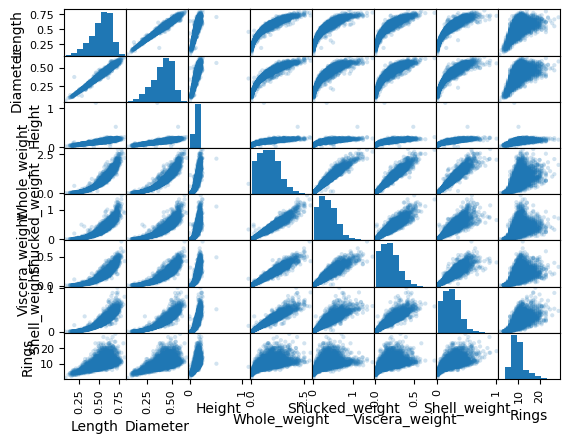

In [31]:
_ = pd.plotting.scatter_matrix(abalone, alpha=0.2)

- Each row and column refers to a column of the data frame.
- On the diagonal, where the row and column refer to the same column of the data frame, a histogram of the column is shown.
- The other subplots show scatterplots of the two variables.
- This lets you see correlations and dependencies pretty easily.
- For example, it turns out that the length, diameter, and height of an abalone are extremely correlated.

In [32]:
abalone.corr(numeric_only=True)

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


Column names are much better than column indices 
- Column names help you write more maintainable and robust code.

Column Names Support Higher Level Patterns 

Starts with your code "knowing" what data you have...

- Writing queries vs individual operations
- Write what to do -> write what you want
- Looking forward: AI will be helping here.

Thinking in terms of column names instead of column indexes, column names help you stay focused on what you want instead of how exactly to implement that.

- Example of how mundane chart creation is much easier using data frames.

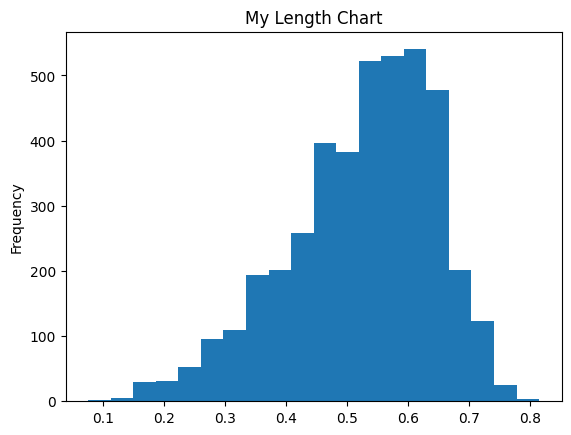

In [34]:
_ = abalone['Length'].plot(kind='hist', bins=20, title='My Length Chart') 
#underscore is used as a throwaway variable 
    # you don't actually intend to use that result later in the code. You are only running the function for its side effect—in this case, displaying the chart.

How Pandas Describes Their Data Frames 

- Two-dimensional, size-mutable, potentially heterogeneous tabular data.
- Data structure also contains labeled axes (rows and columns). Arithmetic operations align on both row and column labels. Can be thought of as a dict-like container for Series objects. The primary pandas data structure.
- Arithmetic operations align on both row and column labels. 
- Can be thought of as a dict-like container for series objects. 
- The primary pandas data structure 
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html 
- Two dimensional refers to the rows and columns.
- Columns are easy to add, but you can add rows if necessary.
- And different columns can be different types.
- The axes labels mentioned are the label values and column names.
- And we already talked about data frames looking similar to dictionaries of series.

Code Example: Inspecting Data Frames 

In [1]:
import pandas as pd
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/abalone.tsv", sep="\t")

In [2]:
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [3]:
abalone.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [4]:
abalone["Length"]

0       0.455
1       0.350
2       0.530
3       0.440
4       0.330
        ...  
4172    0.565
4173    0.590
4174    0.600
4175    0.625
4176    0.710
Name: Length, Length: 4177, dtype: float64

- If we look at one column, it has some similarities to the data frame, but isn't quite the same.
- The formatting is not as pretty for sure.
- We do see two columns of values, one for the index values and one for the selected column's values.
- It still has a name, a length, and a data type.

In [5]:
type(abalone["Length"])

pandas.core.series.Series

- For example, adding a new column to a data frame will be adding a new series, and selecting rows of a data frame will be selecting the same rows from all the series.

In [6]:
abalone["Length"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4177 entries, 0 to 4176
Series name: Length
Non-Null Count  Dtype  
--------------  -----  
4177 non-null   float64
dtypes: float64(1)
memory usage: 32.8 KB


- Like with data frames, you can call an info method on pandas series objects, and get a summary of their memory usage and types.
- Data frames and series have many corresponding attributes and member functions, so I'll look at them both in the following examples.

In [7]:
abalone["Rings"].dtype

dtype('int64')

- Type information is available for each column.
- Generally this will match up with NumPy data types.
- This is one of the exceptions where data frames don't have an attribute of series.
- Data frames lack a data type because their series may have different data types.

In [ ]:
abalone.index

RangeIndex(start=0, stop=4177, step=1)

- Series have an index like data frames.
- Data frames and their series should have matching data frames.

In [9]:
abalone.shape

(4177, 9)

- The data frame shape is the number of rows and the number of columns.
- This is the shape that would be used if the whole data frame was converted into a NumPy array.

In [10]:
abalone["Rings"].shape

(4177,)

- Individual columns have their own shape which is one dimensional, just the number of rows.
- These mirror the NumPy arrays that you would use to implement them independently, and which pandas usually uses internally.

In [11]:
abalone.size

37593

- Data frame sizes are the number of elements across series, so the number of rows times the number of columns.

In [12]:
abalone["Rings"].size

4177

- While the size of a series is the number of rows.

In [17]:
abalone.flags 

#flags attribute returns a Pandas Options object that displays the current internal settings or "flags" that are influencing how Pandas operates on that specific abalone DataFrame.

#provide internal configuration settings that control how the DataFrame or Series behaves, particularly concerning memory efficiency and data integrity.

<Flags(allows_duplicate_labels=True)>

In [18]:
abalone["Rings"].flags

<Flags(allows_duplicate_labels=True)>

- Both data frames and series have control flags tweaking its behavior.

In [19]:
abalone["Rings"].array

<NumpyExtensionArray>
[15,  7,  9, 10,  7,  8, 20, 16,  9, 19,
 ...
  9,  8, 10, 10,  8, 11, 10,  9, 10, 12]
Length: 4177, dtype: int64

- One more thing that series have that data frames do not is an array attribute for their internal data representation.
- Each pandas series wraps a pandas array object.
- Usually those array objects are thin wrappers around NumPy array.
- There are a few specialized array wrappers, particularly around large files.

In [21]:
abalone["Rings"].to_numpy() 

#to_numpy: This is the Pandas method that efficiently converts that selected Series (or DataFrame) into its underlying, high-performance NumPy array

array([15,  7,  9, ...,  9, 10, 12], shape=(4177,))

- Every pandas series can be converted into a matching NumPy array.
- Usually this will be a view into the NumPy array that the series wraps.

In [22]:
abalone.to_numpy()

array([['M', 0.455, 0.365, ..., 0.101, 0.15, 15],
       ['M', 0.35, 0.265, ..., 0.0485, 0.07, 7],
       ['F', 0.53, 0.42, ..., 0.1415, 0.21, 9],
       ...,
       ['M', 0.6, 0.475, ..., 0.2875, 0.308, 9],
       ['F', 0.625, 0.485, ..., 0.261, 0.296, 10],
       ['M', 0.71, 0.555, ..., 0.3765, 0.495, 12]],
      shape=(4177, 9), dtype=object)

- You can convert a whole pandas data frame into a NumPy array.
- If all of the columns have the same NumPy data type, the NumPy array will share that type.

Data Manipulation with Pandas

- NumPy and its ndarray object, which provides efficient storage and manipulation of dense typed arrays in Python 
    - NumPy's ndarray data structure provides essential features for the type of clean, well-organized data typically seen in numerical computing tasks.
    - Limitations become clear when we need more flexibility (e.g., attaching labels to data, working with missing data, etc.) and when attempting operations that do not map well to element-wise broadcasting (e.g., groupings, pivots, etc.), each of which is an important piece of analyzing the less structured data available in many forms in the world around us.
- Pandas provides an efficient implementation of a DataFrame
    - DataFrames are essentially multidimensional arrays with attached row and column labels, and often with heterogeneous types and/or missing data. 
    - Offering a convenient storage interface for labeled data, Pandas implements a number of powerful data operations familiar to users of both database frameworks and spreadsheet programs.
    - Pandas, and in particular its Series and DataFrame objects, builds on the NumPy array structure and provides efficient access to these sorts of "data munging" tasks that occupy much of a data scientist's time.

In [23]:
import pandas as pd 

In [25]:
pd?

Type:        module
String form: <module 'pandas' from '/home/codespace/.local/lib/python3.12/site-packages/pandas/__init__.py'>
File:        ~/.local/lib/python3.12/site-packages/pandas/__init__.py
Docstring:  
pandas - a powerful data analysis and manipulation library for Python

**pandas** is a Python package providing fast, flexible, and expressive data
structures designed to make working with "relational" or "labeled" data both
easy and intuitive. It aims to be the fundamental high-level building block for
doing practical, **real world** data analysis in Python. Additionally, it has
the broader goal of becoming **the most powerful and flexible open source data
analysis / manipulation tool available in any language**. It is already well on
its way toward this goal.

Main Features
-------------
Here are just a few of the things that pandas does well:

  - Easy handling of missing data in floating point as well as non-floating
    point data.
  - Size mutability: columns can be inser

Introducing Pandas Objects 

- 3 fundamental Panda data structures: the Series, DataFrame, and Index 

In [2]:
import numpy as np
import pandas as pd

The Pandas Series Object 
-  one-dimensional array of indexed data. It can be created from a list or array as follows:

In [3]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

- Series wraps both a sequence of values and a sequence of indices, which we can access with the values and index attributes. The values are simply a familiar NumPy array:

In [4]:
data.values

array([0.25, 0.5 , 0.75, 1.  ])

- The index is an array-like object of type pd.Index

In [5]:
data.index

RangeIndex(start=0, stop=4, step=1)

- Like with a NumPy array, data can be accessed by the associated index via the familiar Python square-bracket notation:

In [6]:
data[1]

np.float64(0.5)

In [7]:
data[1:3]

1    0.50
2    0.75
dtype: float64

Series as generalized NumPy array

- The essential difference between NumPy array and Series object is the presence of the index: while the Numpy Array has an implicitly defined integer index used to access the values, the Pandas Series has an explicitly defined index associated with the values.
    - This explicit index definition gives the Series object additional capabilities.   

In [8]:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
data

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64

- And the item access works as expected:

In [9]:
data['b']

np.float64(0.5)

- We can even use non-contiguous or non-sequential indices: 
    - non-contiguous: not physically next to each other or not forming a continuous sequence 
    

In [10]:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=[2, 5, 3, 7])
data

2    0.25
5    0.50
3    0.75
7    1.00
dtype: float64

In [11]:
data[5]

np.float64(0.5)

Series as specialized dictionary 

- Pandas Series a bit like a specialization of a Python dictionary
    - A dictionary is a structure that maps arbitrary keys to a set of arbitrary values
    - A Series is a structure which maps typed keys to a set of typed values. 
        - This typing is important: just as the type-specific compiled code behind a NumPy array makes it more efficient than a Python list for certain operations, the type information of a Pandas Series makes it much more efficient than Python dictionaries for certain operations.

- Constructing a Series object directly from a Python dictionary:

In [12]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

- Series will be created where the index is drawn from the sorted keys. From here, typical dictionary-style item access can be performed:

In [13]:
population['California']

np.int64(38332521)

- Unlike a dictionary, though, the Series also supports array-style operations such as slicing:

In [15]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

Constructing Series Objects 

pd.Series(data, index=index)
- index is an optional argument 
- data can be one of many entities 

- data can be a list or NumPy array, in which case index defaults to an integer sequence:

In [17]:
pd.Series([2, 4, 6])

0    2
1    4
2    6
dtype: int64

- data can be a scalar, which is repeated to fill the specified index:

In [18]:
pd.Series(5, index=[100, 200, 300])

100    5
200    5
300    5
dtype: int64

- data can be a dictionary, in which index defaults to the sorted dictionary keys:

In [19]:
pd.Series({2:'a', 1:'b', 3:'c'})

2    a
1    b
3    c
dtype: object

- In each case, the index can be explicitly set if a different result is preferred:

In [20]:
pd.Series({2:'a', 1:'b', 3:'c'}, index=[3, 2])

3    c
2    a
dtype: object

- Notice that in this case, the Series is populated only with the explicitly identified keys.

The Pandas DataFrame Object 
- Like the Series object discussed in the previous section, the DataFrame can be thought of either as a generalization of a NumPy array, or as a specialization of a Python dictionary.

DataFrame as a generalized NumPy array 
- If a Series is an analog of a one-dimensional array with flexible indices, a DataFrame is an analog of a two-dimensional array with both flexible row indices and flexible column names
-  Just as you might think of a two-dimensional array as an ordered sequence of aligned one-dimensional columns, you can think of a DataFrame as a sequence of aligned Series objects. Here, by "aligned" we mean that they share the same index.



- construct a new Series listing the area of each of the five states discussed in the previous section:

In [21]:
area_dict = {'California': 423967, 'Texas': 695662, 'New York': 141297,
             'Florida': 170312, 'Illinois': 149995}
area = pd.Series(area_dict)
area

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
dtype: int64

- use a dictionary to construct a single two-dimensional object containing this information:

In [22]:
states = pd.DataFrame({'population': population,
                       'area': area})
states

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


- Like the Series object, the DataFrame has an index attribute that gives access to the index labels:

In [23]:
states.index

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')

- Additionally, the DataFrame has a columns attribute, which is an Index object holding the column labels:

In [24]:
states.columns

Index(['population', 'area'], dtype='object')

- Thus the DataFrame can be thought of as a generalization of a two-dimensional NumPy array, where both the rows and columns have a generalized index for accessing the data.

DataFrame as specialized dictionary 
- DataFrame as a specialization of a dictionary. 
    - Where a dictionary maps a key to a value, a DataFrame maps a column name to a Series of column data. 
- For example, asking for the 'area' attribute returns the Series object containing the areas we saw earlier:

In [25]:
states['area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: area, dtype: int64

- In a two-dimesnional NumPy array, data[0] will return the first row. For a DataFrame, data['col0'] will return the first column. 
    - Because of this, it is probably better to think about DataFrames as generalized dictionaries rather than generalized arrays, though both ways of looking at the situation can be useful. 

Constructing DataFrame objects 
1. From a single Series object 
    - A DataFrame is a collection of Series objects, and a single-column DataFrame can be constructed from a single Series:

In [26]:
pd.DataFrame(population, columns=['population'])

,population
California,38332521
Texas,26448193
New York,19651127
Florida,19552860
Illinois,12882135


2. From a list of dicts 
    - Any list of dictionaries can be made into a DataFrame. We'll use a simple list comprehension to create some data:

In [27]:
data = [{'a': i, 'b': 2 * i}
        for i in range(3)]
pd.DataFrame(data)

,a,b
0,0,0
1,1,2
2,2,4


- Even if some keys in the dictionary are missing, Pandas will fill them in with NaN (i.e., "not a number") values:

In [28]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


3. From a dictionary of Series objects 
    - As we saw before, a DataFrame can be constructed from a dictionary of Series objects as well:

In [30]:
pd.DataFrame({'population': population,
              'area': area})

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


4. From a two-dimensional NumPy array
    - Given a two-dimensional array of data, we can create a DataFrame with any specified column and index names. If omitted, an integer index will be used for each:

In [31]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['foo', 'bar'],
             index=['a', 'b', 'c'])

,foo,bar
a,0.240428,0.208264
b,0.903345,0.166464
c,0.354932,0.812204


5. From a NumPy structured array 
    - A Pandas DataFrame operates much like a structured array, and can be created directly from one:

In [32]:
A = np.zeros(3, dtype=[('A', 'i8'), ('B', 'f8')])
A

array([(0, 0.), (0, 0.), (0, 0.)], dtype=[('A', '<i8'), ('B', '<f8')])

In [33]:
pd.DataFrame(A)

,A,B
0,0,0.0
1,0,0.0
2,0,0.0


The Pandas Index Object 
- We have seen here that both the Series and DataFrame objects contain an explicit index that lets you reference and modify data. 
    - This Index object is an interesting structure in itself, and it can be thought of either as an immutable array or as an ordered set (technically a multi-set, as Index objects may contain repeated values). 
        - Those views have some interesting consequences in the operations available on Index objects. 
- As a simple example, let's construct an Index from a list of integers:

In [34]:
ind = pd.Index([2, 3, 5, 7, 11])
ind

Index([2, 3, 5, 7, 11], dtype='int64')

Index as immutable array 
- The Index in many ways operates like an array. For example, we can use standard Python indexing notation to retrieve values or slices:

In [35]:
ind[1]

np.int64(3)

In [36]:
ind[::2]

Index([2, 5, 11], dtype='int64')

- Index objects also have many of the attributes familiar from NumPy arrays:

In [38]:
print(ind.size, ind.shape, ind.ndim, ind.dtype)

# .shape attribute (or property) is used to tell you the size and dimensionality of an array-like object, like a NumPy array or a Pandas DataFrame/Index.

5 (5,) 1 int64


- One difference between Index objects and NumPy arrays is that indices are immutable–that is, they cannot be modified via the normal means:

In [39]:
ind[1] = 0

TypeError: Index does not support mutable operations

- This immutability makes it safer to share indices between multiple DataFrames and arrays, without the potential for side effects from inadvertent index modification.

Index as Ordered Set 
- Pandas objects are designed to facilitate operations such as joins across datasets, which depend on many aspects of set arithmetic. The Index object follows many of the conventions used by Python's built-in set data structure, so that unions, intersections, differences, and other combinations can be computed in a familiar way:

In [40]:
indA = pd.Index([1, 3, 5, 7, 9])
indB = pd.Index([2, 3, 5, 7, 11])

In [41]:
indA & indB  # intersection

Index([0, 3, 5, 7, 9], dtype='int64')

In [42]:
indA | indB  # union

Index([3, 3, 5, 7, 11], dtype='int64')

In [45]:
indA ^ indB  # symmetric difference: the symmetric difference between two sets contains all the elements that are in either one of the sets, but not in both.

Index([3, 0, 0, 0, 2], dtype='int64')

Numpy vs. Pandas

- The core message is that they are not rivals, as Pandas is built directly on top of NumPy

1. NumPy: The Foundation
- Goal: Brought scientific computing to Python, released in 2005 
- Strength: Excels in numerical analysis, linear algebra, and simulations 
- Data Structure: Primarily works with multi-dimensional array objects 
- Performance: Uses specialized sub-programs like BLAS (Basic Linear Algebra Subprograms) and LAPACK to handle large amounts of data much faster than Python's built-in functions

2. Pandas: The Data Manipulation Toolkit
- Goal: Created in 2008 to provide a powerful tool for quantitative analysis, especially on financial data 
- Strength: Excels at data analysis and manipulation, particularly working with a wide range of data sources and missing data 
- Data Structure: Excels at working with tabular data (DataFrames and Series) 
- Capabilities: Provides straightforward methods for loading, reshaping, pivoting, merging, and joining data 

3. The Relationship
- The video concludes that there isn't a "winner" because they serve different purposes:
    - Pandas builds on NumPy, meaning most of NumPy's numerical methods are available through Pandas 
    - While Pandas is more powerful for data analysis, the added functionality comes with some overhead in performance and complexity. However, for very large datasets, Pandas implements functions optimized with C and Cython that can sometimes be faster than their pure NumPy equivalents 
    - The recommended approach is to start with NumPy and only move to Pandas if your needs (like tabular data manipulation) lead you there. 